In [11]:
import numpy as np
#this is relatively simple. 
#lets first define the state initialization function
def make_zero_state(n_qubits):
    state = np.zeros(2**n_qubits, dtype=complex)
    state[0] = 1.0
    return state

#Ry gate definition ()
def make_RY(theta):
    c = np.cos(theta / 2)
    s = np.sin(theta / 2)
    return np.array([[c, -s],
                     [s,  c]], dtype=complex)

#amplitude pair update
def apply_single_qubit_gate(state, n_qubits, target, U):
    dim    = 2**n_qubits
    step   = 2**(n_qubits - 1 - target)
    period = step * 2
    for base in range(0, dim, period):
        for i in range(step):
            i0 = base + i
            i1 = base + i + step
            a0 = state[i0]
            a1 = state[i1]
            state[i0] = U[0,0]*a0 + U[0,1]*a1
            state[i1] = U[1,0]*a0 + U[1,1]*a1
    return state


#Run
n_qubits = 1
theta    = np.pi / 3

#|1> by flipping the zero state
state    = make_zero_state(n_qubits)
state[0] = 0.0
state[1] = 1.0

print("Initial state:")
print(f"  psi[0] = {state[0]},  psi[1] = {state[1]}")
#apply the Ry gate
U = make_RY(theta)
state = apply_single_qubit_gate(state, n_qubits, target=0, U=U)

#print the results
print(f"\nAfter $R_y$ gate:")
print(f"  psi[0] = {state[0].real:.4f}")
print(f"  psi[1] = {state[1].real:.4f}")

#calculate the probabilities
p0 = abs(state[0])**2
p1 = abs(state[1])**2
Z  = p0 - p1

print(f"\nMeasurement probabilities:")
print(f"  p(0) = {p0:.4f}")
print(f"  p(1) = {p1:.4f}")
print(f"  <Z>  = {Z:.4f}")
print(f"\n  Unitarity check: p(0)+p(1) = {p0+p1:.4f}  (expected: 1.0)")


Initial state:
  psi[0] = 0j,  psi[1] = (1+0j)

After $R_y$ gate:
  psi[0] = -0.5000
  psi[1] = 0.8660

Measurement probabilities:
  p(0) = 0.2500
  p(1) = 0.7500
  <Z>  = -0.5000

  Unitarity check: p(0)+p(1) = 1.0000  (expected: 1.0)


In [9]:
#cnot gate 
def apply_cnot(state, n_qubits, control, target):
    dim          = 2**n_qubits
    control_mask = 2**(n_qubits - 1 - control)
    target_mask  = 2**(n_qubits - 1 - target)
    for idx in range(dim):
        if (idx & control_mask) != 0:
            flipped = idx ^ target_mask
            if idx < flipped:
                state[idx], state[flipped] = state[flipped], state[idx]
    return state

#prepare Ry(pi/3)|1> x |1>  -  |11> is index 3
n_qubits = 2
state    = make_zero_state(n_qubits)
state[0] = 0.0
state[3] = 1.0

print("Initial state |11>:")
for i in range(4):
    print(f"  psi[{i}] = {state[i]}")

#apply Ry(pi/3) on qubit 0
U     = make_RY(np.pi / 3)
state = apply_single_qubit_gate(state, n_qubits, target=0, U=U)

print("\nAfter Ry(pi/3) on qubit 0:")
for i in range(4):
    print(f"  psi[{i}] = {state[i].real:.4f}")

#apply cnot: control=0, target=1
state = apply_cnot(state, n_qubits, control=0, target=1)

print("\nAfter CNOT (control=0, target=1):")
for i, label in enumerate(['00','01','10','11']):
    print(f"  psi[{label}] = {state[i].real:.4f}")

#probabilities
probs = [abs(state[i])**2 for i in range(4)]
print(f"\nMeasurement probabilities:")
for i, label in enumerate(['00','01','10','11']):
    print(f"  p({label}) = {probs[i]:.4f}")
print(f"\n  Unitarity check: p(00)+p(01)+p(10)+p(11) = {sum(probs):.4f}")

Initial state |11>:
  psi[0] = 0j
  psi[1] = 0j
  psi[2] = 0j
  psi[3] = (1+0j)

After Ry(pi/3) on qubit 0:
  psi[0] = 0.0000
  psi[1] = -0.5000
  psi[2] = 0.0000
  psi[3] = 0.8660

After CNOT (control=0, target=1):
  psi[00] = 0.0000
  psi[01] = -0.5000
  psi[10] = 0.8660
  psi[11] = 0.0000

Measurement probabilities:
  p(00) = 0.0000
  p(01) = 0.2500
  p(10) = 0.7500
  p(11) = 0.0000

  Unitarity check: p(00)+p(01)+p(10)+p(11) = 1.0000


In [15]:
#Rx gate definition
def make_RX(theta):
    c = np.cos(theta / 2)
    s = np.sin(theta / 2)
    return np.array([[c,       -1j*s],
                     [-1j*s,   c    ]], dtype=complex)

#vqc forward pass: 2 qubits, 2 layers (Rx, Ry, CNOT)
n_qubits = 2
n_layers = 2
state    = make_zero_state(n_qubits)

print("Initial state |00>:")
for i, label in enumerate(['00','01','10','11']):
    print(f"  psi[{label}] = {state[i]}")

for layer in range(n_layers):
    print(f"\n Layer {layer+1} : ")

    #Rx(pi/2) on both qubits
    Rx = make_RX(np.pi / 2)
    state = apply_single_qubit_gate(state, n_qubits, target=0, U=Rx)
    state = apply_single_qubit_gate(state, n_qubits, target=1, U=Rx)
    print(f"After Rx(pi/2) on both qubits:")
    for i, label in enumerate(['00','01','10','11']):
        print(f"  psi[{label}] = {state[i].real:.4f} {state[i].imag:+.4f}j")

    #Ry(pi/3) on both qubits
    Ry = make_RY(np.pi / 3)
    state = apply_single_qubit_gate(state, n_qubits, target=0, U=Ry)
    state = apply_single_qubit_gate(state, n_qubits, target=1, U=Ry)
    print(f"After Ry(pi/3) on both qubits:")
    for i, label in enumerate(['00','01','10','11']):
        print(f"  psi[{label}] = {state[i].real:.4f} {state[i].imag:+.4f}j")

    #cnot: control=1, target=0
    state = apply_cnot(state, n_qubits, control=0, target=1)
    print(f"After CNOT (control=1, target=0):")
    for i, label in enumerate(['00','01','10','11']):
        print(f"  psi[{label}] = {state[i].real:.4f} {state[i].imag:+.4f}j")

#final probabilities
probs = [abs(state[i])**2 for i in range(4)]
print(f"\nFinal measurement probabilities:")
for i, label in enumerate(['00','01','10','11']):
    print(f"  p({label}) = {probs[i]:.4f}")
print(f"\n  Unitarity check: sum = {sum(probs):.4f}")

Initial state |00>:
  psi[00] = (1+0j)
  psi[01] = 0j
  psi[10] = 0j
  psi[11] = 0j

 Layer 1 : 
After Rx(pi/2) on both qubits:
  psi[00] = 0.5000 +0.0000j
  psi[01] = 0.0000 -0.5000j
  psi[10] = 0.0000 -0.5000j
  psi[11] = -0.5000 +0.0000j
After Ry(pi/3) on both qubits:
  psi[00] = 0.2500 +0.4330j
  psi[01] = 0.4330 -0.2500j
  psi[10] = 0.4330 -0.2500j
  psi[11] = -0.2500 -0.4330j
After CNOT (control=1, target=0):
  psi[00] = 0.2500 +0.4330j
  psi[01] = 0.4330 -0.2500j
  psi[10] = -0.2500 -0.4330j
  psi[11] = 0.4330 -0.2500j

 Layer 2 : 
After Rx(pi/2) on both qubits:
  psi[00] = -0.4330 +0.2500j
  psi[01] = 0.4330 -0.2500j
  psi[10] = -0.2500 -0.4330j
  psi[11] = -0.2500 -0.4330j
After Ry(pi/3) on both qubits:
  psi[00] = -0.4665 +0.3750j
  psi[01] = 0.3080 +0.2165j
  psi[10] = -0.3750 +0.0335j
  psi[11] = -0.2165 -0.5580j
After CNOT (control=1, target=0):
  psi[00] = -0.4665 +0.3750j
  psi[01] = 0.3080 +0.2165j
  psi[10] = -0.2165 -0.5580j
  psi[11] = -0.3750 +0.0335j

Final measure

In [ ]:
import cProfile
import pstats
import io

#wrap the vqc in a function to profile
def run_vqc(n_qubits=2, n_layers=2):
    state = make_zero_state(n_qubits)
    Rx    = make_RX(np.pi / 2)
    Ry    = make_RY(np.pi / 3)
    for layer in range(n_layers):
        for q in range(n_qubits):
            state = apply_single_qubit_gate(state, n_qubits, target=q, U=Rx)
        for q in range(n_qubits):
            state = apply_single_qubit_gate(state, n_qubits, target=q, U=Ry)
        state = apply_cnot(state, n_qubits, control=0, target=1)
    return state

for n in [2, 10, 15, 18]:
    pr = cProfile.Profile()
    pr.enable()
    run_vqc(n_qubits=n, n_layers=6)
    pr.disable()

    stream = io.StringIO()
    ps     = pstats.Stats(pr, stream=stream).sort_stats('cumulative')
    ps.print_stats(20)
    print(f" n_qubits={n}, n_layers=6 ")
    print(stream.getvalue())



=== n_qubits=2, n_layers=6 ===
         38 function calls in 0.000 seconds

   Ordered by: cumulative time

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        1    0.000    0.000    0.000    0.000 /tmp/ipykernel_373063/737665920.py:6(run_vqc)
       24    0.000    0.000    0.000    0.000 /tmp/ipykernel_373063/107632639.py:17(apply_single_qubit_gate)
        1    0.000    0.000    0.000    0.000 /tmp/ipykernel_373063/4054556366.py:2(make_RX)
        1    0.000    0.000    0.000    0.000 /tmp/ipykernel_373063/107632639.py:4(make_zero_state)
        2    0.000    0.000    0.000    0.000 {built-in method numpy.array}
        6    0.000    0.000    0.000    0.000 /tmp/ipykernel_373063/2186494372.py:2(apply_cnot)
        1    0.000    0.000    0.000    0.000 {built-in method numpy.zeros}
        1    0.000    0.000    0.000    0.000 /tmp/ipykernel_373063/107632639.py:10(make_RY)
        1    0.000    0.000    0.000    0.000 {method 'disable' of '_lsprof.Profiler'

Profiling (varying number of qubits, layers=6):
qubits	total_time	RX/RY_time	CNOT_time
2	0.000092	0.000038	0.000006
5	0.000612	0.000577	0.000018
8	0.006178	0.006049	0.000106
10	0.030318	0.029870	0.000419
12	0.143174	0.141439	0.001693
15	1.341808	1.329127	0.012608
18	11.847229	11.751799	0.095205


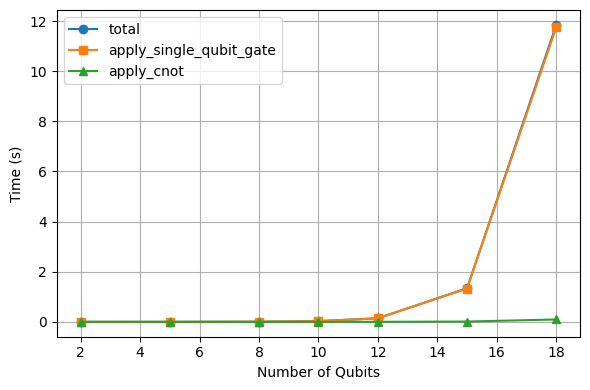


Profiling (varying number of layers, qubits=15):
layers	total_time	RX/RY_time	CNOT_time
1	0.207629	0.205561	0.002035
2	0.416196	0.412124	0.004043
3	0.625169	0.619003	0.006133
4	0.833787	0.825607	0.008139
5	1.038284	1.028174	0.010048
6	1.242427	1.230476	0.011893
8	1.661784	1.645677	0.016035
10	2.077654	2.057746	0.019814


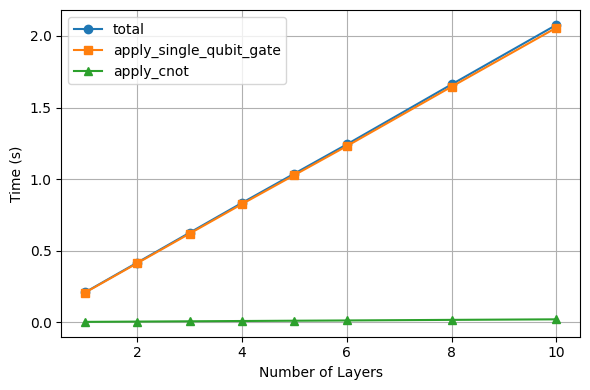

In [24]:
import matplotlib.pyplot as plt
import cProfile
import pstats
import io
import numpy as np

def profile_vqc(n_qubits, n_layers):
    pr = cProfile.Profile()
    pr.enable()
    run_vqc(n_qubits=n_qubits, n_layers=n_layers)
    pr.disable()

    times = {'apply_single_qubit_gate': 0, 'apply_cnot': 0, 'total': 0}
    for item in pr.getstats():
        code    = item[0]
        cumtime = item[3]
        #code object has co_name attribute, strings have __contains__
        fname = code.co_name if hasattr(code, 'co_name') else str(code)
        if 'apply_single_qubit_gate' in fname:
            times['apply_single_qubit_gate'] += cumtime
        elif 'apply_cnot' in fname:
            times['apply_cnot'] += cumtime
        elif 'run_vqc' in fname:
            times['total'] += cumtime
    return times

# ── Plot 1: varying qubit count (fixed layers=6) ──
qubit_counts = [2, 5, 8, 10, 12, 15, 18]
fixed_layers = 6

sq_times, cx_times, total_times = [], [], []
for n in qubit_counts:
    t = profile_vqc(n, fixed_layers)
    sq_times.append(t['apply_single_qubit_gate'])
    cx_times.append(t['apply_cnot'])
    total_times.append(t['total'])

# Print the final numbers for varying qubits
print("Profiling (varying number of qubits, layers=6):")
print("qubits\ttotal_time\tRX/RY_time\tCNOT_time")
for i, n in enumerate(qubit_counts):
    print(f"{n}\t{total_times[i]:.6f}\t{sq_times[i]:.6f}\t{cx_times[i]:.6f}")

fig1, ax1 = plt.subplots(figsize=(6, 4))
ax1.plot(qubit_counts, total_times,  marker='o', label='total')
ax1.plot(qubit_counts, sq_times,     marker='s', label='apply_single_qubit_gate')
ax1.plot(qubit_counts, cx_times,     marker='^', label='apply_cnot')
ax1.set_xlabel("Number of Qubits")
ax1.set_ylabel("Time (s)")
# ax1.set_title("Runtime vs Qubit Count (fixed 6 layers)")  # No title per instructions
ax1.legend()
ax1.grid(True)
plt.tight_layout()  # Ensure tight layout as requested
plt.savefig("profiling_qubits.pdf", dpi=150, bbox_inches="tight")  # Save as PDF, not PNG
plt.show()

# ── Plot 2: varying depth (fixed qubits=15) ──
layer_counts = [1, 2, 3, 4, 5, 6, 8, 10]
fixed_qubits = 15

sq_times2, cx_times2, total_times2 = [], [], []
for l in layer_counts:
    t = profile_vqc(fixed_qubits, l)
    sq_times2.append(t['apply_single_qubit_gate'])
    cx_times2.append(t['apply_cnot'])
    total_times2.append(t['total'])

# Print the final numbers for varying layers
print("\nProfiling (varying number of layers, qubits=15):")
print("layers\ttotal_time\tRX/RY_time\tCNOT_time")
for i, l in enumerate(layer_counts):
    print(f"{l}\t{total_times2[i]:.6f}\t{sq_times2[i]:.6f}\t{cx_times2[i]:.6f}")

fig2, ax2 = plt.subplots(figsize=(6, 4))
ax2.plot(layer_counts, total_times2,  marker='o', label='total')
ax2.plot(layer_counts, sq_times2,     marker='s', label='apply_single_qubit_gate')
ax2.plot(layer_counts, cx_times2,     marker='^', label='apply_cnot')
ax2.set_xlabel("Number of Layers")
ax2.set_ylabel("Time (s)")
# ax2.set_title("Runtime vs Circuit Depth (fixed 15 qubits)")  # No title per instructions
ax2.legend()
ax2.grid(True)
plt.tight_layout()  # Ensure tight layout as requested
plt.savefig("profiling_layers.pdf", dpi=150, bbox_inches="tight")  # Save as PDF, not PNG
plt.show()